# Mario RL Result Visualization

This notebook allows you to view the gameplay videos generated by the RL agent.
Since the videos are saved as `.avi` files (MJPG codec) for compatibility during recording, they cannot be played directly by the browser's HTML5 video player. 
Instead, we use `matplotlib` and `ipywidgets` to render the video frames directly in the notebook.

In [1]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import os
import glob
import time

In [2]:
def play_video(video_path, fps=30, speed_up=0.5):
    """Plays an AVI video file in the notebook."""
    if not os.path.exists(video_path):
        print(f"Video not found: {video_path}")
        return

    cap = cv2.VideoCapture(video_path)
    
    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Display frame
            plt.axis('off')
            plt.imshow(frame)
            plt.show()
            
            # Simulation of frame rate
            clear_output(wait=True)
            time.sleep(1/fps * speed_up) # Speed up slightly as display overhead is high
            
    except KeyboardInterrupt:
        print("Stopped.")
    finally:
        cap.release()

In [3]:
# List available videos
video_dir = 'videos'
videos = sorted(glob.glob(os.path.join(video_dir, '*.avi')), key=os.path.getmtime)

print("Available Videos:")
for i, v in enumerate(videos):
    print(f"{i}: {v}")

Available Videos:
0: videos/episode_52.avi


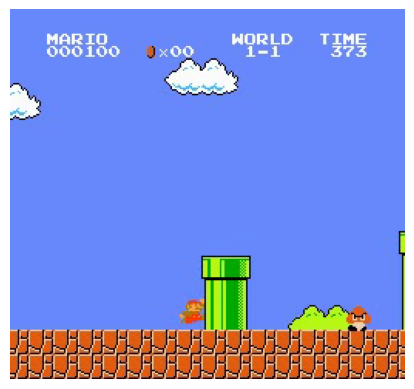

In [4]:
# Play the latest video
if videos:
    latest_video = videos[-1]
    print(f"Playing latest video: {latest_video}")
    play_video(latest_video, fps=120, speed_up=0.0000000001)
else:
    print("No videos found in videos/ directory.")